<a href="https://colab.research.google.com/github/M4rck0/Procesamiento_Clasificacion_Datos/blob/main/Tarea_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerías
import os
import glob
import librosa
import numpy as np
import pandas as pd

import pywt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

In [2]:
# Dataset
ruta = kagglehub.dataset_download("joserzapata/free-spoken-digit-dataset-fsdd")
print("Ruta:", ruta)

Using Colab cache for faster access to the 'free-spoken-digit-dataset-fsdd' dataset.
Ruta: /kaggle/input/free-spoken-digit-dataset-fsdd


In [6]:
# Leer audios y crear etiquetas
ruta_audio = os.path.join(ruta, "recordings")
archivos = glob.glob(os.path.join(ruta_audio, "*.wav"))
datos = []

for archivo in archivos:
    nombre = os.path.basename(archivo)
    digito = int(nombre.split("_")[0])
    datos.append({
            "archivo": archivo,
            "digito": digito
        })

df = pd.DataFrame(datos)
df

,archivo,digito
0,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,0
1,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,2
2,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,4
3,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,1
4,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,9
...,...,...
2995,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,1
2996,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,2
2997,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,8
2998,/kaggle/input/free-spoken-digit-dataset-fsdd/r...,0


In [7]:
def extraer_wavelet(archivo):

    # Leer audio
    audio, sr = librosa.load(archivo, sr=None)

    # Transformada wavelet
    coeficientes = pywt.wavedec(audio, wavelet="db1", level=6)
    caracteristicas = []

    for c in coeficientes:
        caracteristicas.extend([
                np.mean(c),
                np.std(c),
                np.max(c),
                np.min(c),
                np.sum(c**2)
            ])


    return caracteristicas

In [8]:
# Crear matriz X y variable objetivo y
X = []
y = []

for indice, fila in df.iterrows():
    caracteristicas = extraer_wavelet(fila["archivo"])
    X.append(caracteristicas)
    y.append(fila["digito"])

X = np.array(X)
y = np.array(y)

X.shape, y.shape

((3000, 35), (3000,))

In [10]:
# Train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

In [11]:
# Entrenar clasificador
modelo = RandomForestClassifier(n_estimators=200, random_state=123)
modelo.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=123)

In [12]:
# Evaluar
pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, pred))

Accuracy: 0.7433333333333333
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        60
           1       0.75      0.65      0.70        60
           2       0.80      0.82      0.81        60
           3       0.64      0.63      0.64        60
           4       0.82      0.90      0.86        60
           5       0.73      0.82      0.77        60
           6       0.75      0.87      0.81        60
           7       0.73      0.58      0.65        60
           8       0.68      0.60      0.64        60
           9       0.67      0.75      0.71        60

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



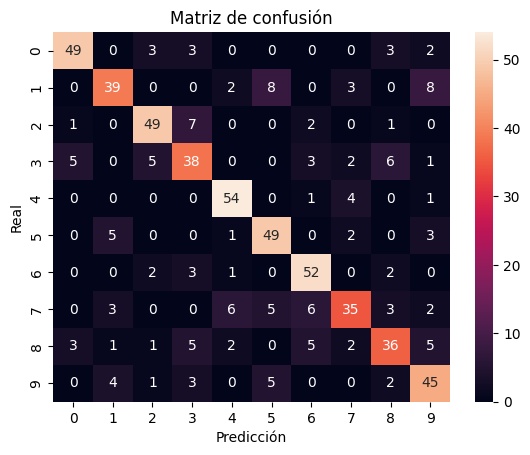

In [13]:
# Matriz de confusión
cm = confusion_matrix(y_test, pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

In [10]:
# Nuevo audio
archivo_nuevo = (ruta_audio + "/7_jackson_32.wav")
caracteristicas = extraer_wavelet(archivo_nuevo)
resultado = modelo.predict([caracteristicas])
print("El dígito predicho es:", resultado[0])

El dígito predicho es: 7
